# Building chains of transformations and models with the `Pipeline` class on the iris dataset

### Table of Contents

* [I. Import libraries](#chapter1)
* [II. Load dataset](#chapter2)
* [III. Train/Test Split](#chapter3)
* [IV. Exploratory Data Analysis](#chapter4)
    * [IV.A Summary of data frame](#section4_1)
    * [IV.B Statistical graphical techniques](#section4_2)
* [V. Preprocessing](#chapter5)
    * [V.A Feature Engineering](#section5_1)
        * [V.A.1 Standardization](#section5_1_)
* [VI. Training of models](#chapter6)
    * [VI.A Build Pipeline](#section6_1)
    * [VI.B Model evaluation](#section6_2)
* [VII. Grid-Searching Preprocessing Steps and Model Parameters](#chapter7)

## I. Import libraries <a class="anchor" id="chapter1"></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn')
from time import time

In [2]:
from sklearn.datasets import load_iris

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [5]:
from sklearn.metrics import classification_report

## II. Load dataset <a class="anchor" id="chapter2"></a>

In [6]:
iris = load_iris(return_X_y=False)

In [7]:
iris.data.shape, iris.target.shape

((150, 4), (150,))

In [8]:
data = pd.DataFrame(iris.data)
data.columns = ['sepal length', 'sepal width', 'petal length', 'petal width']
target = pd.DataFrame(iris.target)
target.columns = ['class']
iris = pd.concat([data, target], axis=1)

In [9]:
iris

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## III. Training/Test Dataset Split <a class="anchor" id="chapter3"></a>

In [10]:
def train_test_size(X_train: pd.core.frame.DataFrame,
                    X_test: pd.core.frame.DataFrame
                   ) -> None:
    
    print(f'Number of data points in training dataset: {X_train.shape[0]}')
    print(f'Number of data points in test dataset: {X_test.shape[0]}')
    
    proportion = np.round((X_train.shape[0] - X_test.shape[0]) / X_train.shape[0], 4) * 100
    
    print(f'Proportion of the dataset included in the training split: {proportion}%')
    print(f'Proportion of the dataset included in the test split: {100 - proportion}%')
    
    return

In [11]:
def class_counts(y: pd.core.frame.DataFrame) -> None:
    
    count0 = y[y['class'] == 0].shape[0]
    count1 = y[y['class'] == 1].shape[0]
    count2 = y[y['class'] == 2].shape[0]
    
    print(f'Counts of classes in training dataset: {(count0, count1, count2)}')
    
    return

In [12]:
def class_proportions(y: pd.core.frame.DataFrame) -> None:
    
    proportion0 = np.round(y[y['class'] == 0].shape[0] / y.shape[0], 4) * 100
    proportion1 = np.round(y[y['class'] == 1].shape[0] / y.shape[0], 4) * 100
    proportion2 = np.round(y[y['class'] == 2].shape[0] / y.shape[0], 4) * 100
    
    print(f'Proportions of classes in training dataset: {(proportion0, proportion1, proportion2)}')
    
    return

In [13]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=0, stratify=target)

In [14]:
train_test_size(X_train, X_test)

Number of data points in training dataset: 120
Number of data points in test dataset: 30
Proportion of the dataset included in the training split: 75.0%
Proportion of the dataset included in the test split: 25.0%


In [15]:
class_counts(y_train)

Counts of classes in training dataset: (40, 40, 40)


In [16]:
class_proportions(y_train)

Proportions of classes in training dataset: (33.33, 33.33, 33.33)


## IV. Exploratory Data Analysis <a class="anchor" id="chapter4"></a>

### IV.A Summary of data frame <a class="anchor" id="section4_1"></a>

In [17]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 45 to 106
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  120 non-null    float64
 1   sepal width   120 non-null    float64
 2   petal length  120 non-null    float64
 3   petal width   120 non-null    float64
dtypes: float64(4)
memory usage: 4.7 KB


### IV.B Statistical graphical techniques <a class="anchor" id="section4_2"></a>

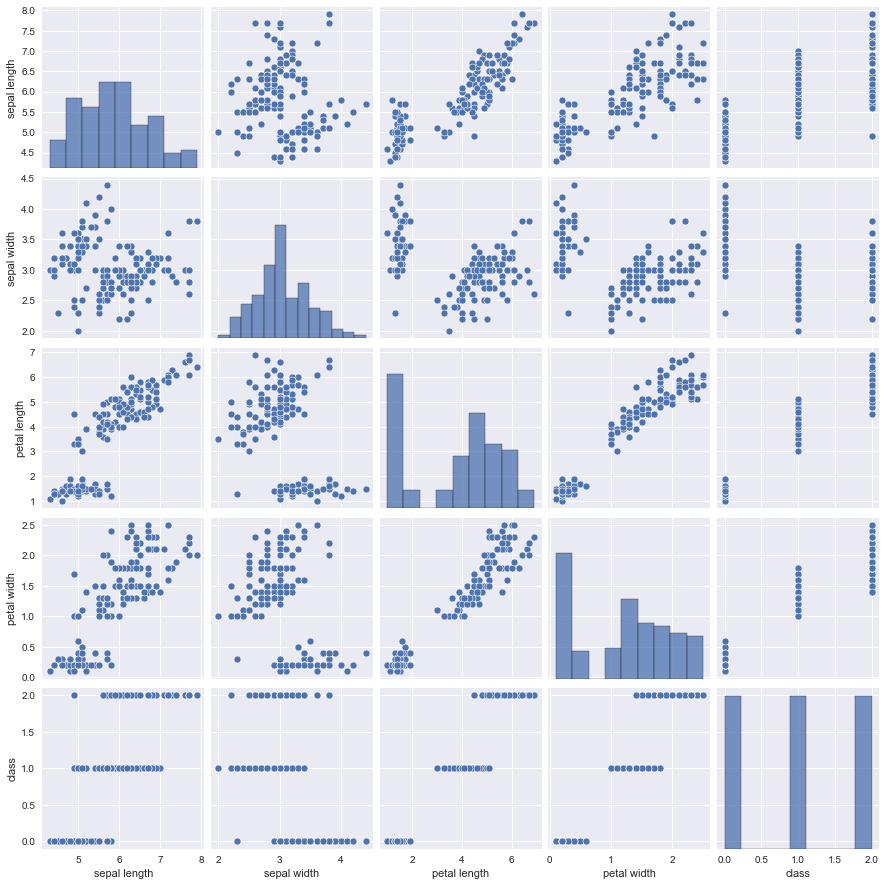

In [18]:
sns.pairplot(iris, palette='crest')
plt.show()

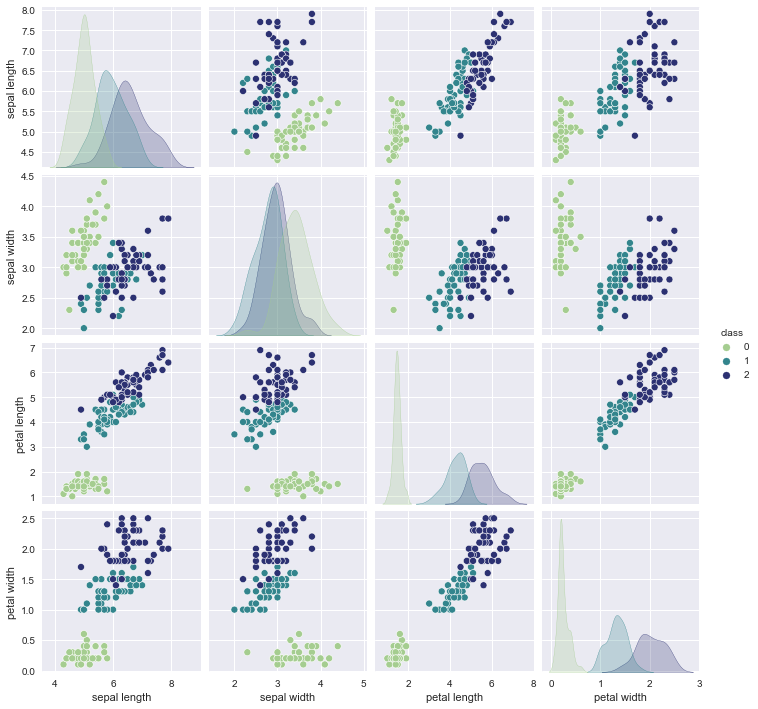

In [19]:
sns.pairplot(iris, hue='class', palette='crest')
plt.show()

## V. Preprocessing <a class="anchor" id="chapter5"></a>

### V.A Feature Engineering <a class="anchor" id="section5_1"></a>

#### V.A.1 Standardization <a class="anchor" id="section5_1_1"></a>

In [20]:
scaler = StandardScaler()

## VI. Training of models <a class="anchor" id="chapter6"></a>

### VI.A Build Pipeline <a class="anchor" id="section6_1"></a>

In [21]:
pipeline = Pipeline([('standardization', scaler), ('logisticregression', LogisticRegression())])

In [22]:
y_train = np.ravel(y_train)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardization', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [23]:
y_true, y_pred = y_test, pipeline.predict(X_test)

### VI.B Model evaluation <a class="anchor" id="section6_2"></a>

In [24]:
score = pipeline.score(X_test, y_test)
print(f'{score:.4f}')

0.9667


In [25]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## VII. Grid-Searching Preprocessing Steps and Model Parameters <a class="anchor" id="chapter7"></a>

In [26]:
C = [0.0001, 0.001, 0.01, 0.1, 10, 100]

param_grid = {'logisticregression__C': C
             }

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=10, n_jobs = -1).fit(X_train, y_train)

In [27]:
print(grid.best_estimator_)

Pipeline(steps=[('standardization', StandardScaler()),
                ('logisticregression', LogisticRegression(C=100))])


In [28]:
grid.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('standardization', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 10,
                                                   100]})

In [29]:
print(grid.cv_results_)

{'mean_fit_time': array([0.01140196, 0.01420052, 0.01720157, 0.01820168, 0.02820246,
       0.03418794]), 'std_fit_time': array([0.00101976, 0.0016626 , 0.00676463, 0.00534446, 0.00526878,
       0.00555543]), 'mean_score_time': array([0.00450044, 0.00930045, 0.00299954, 0.00329981, 0.00400033,
       0.00299988]), 'std_score_time': array([0.00390691, 0.01441696, 0.00044788, 0.00090008, 0.00109493,
       0.00089434]), 'param_logisticregression__C': masked_array(data=[0.0001, 0.001, 0.01, 0.1, 10, 100],
             mask=[False, False, False, False, False, False],
       fill_value='?',
            dtype=object), 'params': [{'logisticregression__C': 0.0001}, {'logisticregression__C': 0.001}, {'logisticregression__C': 0.01}, {'logisticregression__C': 0.1}, {'logisticregression__C': 10}, {'logisticregression__C': 100}], 'split0_test_score': array([0.91666667, 0.91666667, 1.        , 1.        , 1.        ,
       1.        ]), 'split1_test_score': array([0.83333333, 0.91666667, 0.9166666

In [30]:
improved_score = grid.score(X_test, y_test)

In [31]:
print(improved_score)

1.0
